In [1]:
import pandas as pd
import polars as pl
import numpy as np
import matplotlib.pyplot as plt
import gc

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, recall_score, precision_score, f1_score,\
    confusion_matrix, ConfusionMatrixDisplay, average_precision_score

from catboost import CatBoostClassifier
from catboost import utils

Загрузим полный набор данных

In [2]:
train_part1 = pl.read_parquet("../ClearData_for_part_4/train_full.parquet")
train_part1.shape

(85677840, 20)

In [3]:
train_part1.schema

Schema([('event_type_nm', Int16),
        ('event_desc', Int16),
        ('channel_indicator_type', Int16),
        ('channel_indicator_sub_type', Int16),
        ('operaton_amt', Float64),
        ('currency_iso_cd', Int16),
        ('mcc_code', Int16),
        ('pos_cd', Int16),
        ('timezone', Int16),
        ('session_id', Float64),
        ('operating_system_type', Int16),
        ('battery', String),
        ('device_system_version', String),
        ('screen_size', String),
        ('developer_tools', Int16),
        ('phone_voip_call_state', Int16),
        ('web_rdp_connection', Int16),
        ('compromised', Int16),
        ('Hour', Int16),
        ('target', Int16)])

In [4]:
train_part1["target"].value_counts()

target,count
i16,u32
1,51438
0,85626402


In [5]:
pos_class = train_part1.filter(pl.col("target") == 1)
pos_class.shape

(51438, 20)

In [6]:
train_part1 = train_part1.filter(pl.col("target") != 1)
train_part1.shape

(85626402, 20)

In [7]:
neg_class = 13_000_000
train_part1 = train_part1.sample(n=neg_class)

columns = ["event_type_nm", "channel_indicator_type", "channel_indicator_sub_type", "currency_iso_cd", "mcc_code", "pos_cd", "timezone",\
           "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised", "operating_system_type", "event_desc"]

for i in columns:
    train_part1 = train_part1.with_columns(pl.when(pl.col(i) == -1).then(None).otherwise(pl.col(i)).alias(i))
    #train_part1 = train_part1.with_columns(pl.when(pl.col(i) == "-1").then(None).otherwise(pl.col("compromised")).alias("compromised"))

In [8]:
train_part1 = pl.concat([train_part1, pos_class])
train_part1 = train_part1.sample(fraction=1.0, shuffle=True)
train_part1.shape

(13051438, 20)

In [9]:
# cat_features = ["event_type_nm", "event_desc", "channel_indicator_type", "channel_indicator_sub_type", \
#                 "currency_iso_cd", "mcc_code", "pos_cd", "timezone", "operating_system_type", "battery",\
#                 "device_system_version", "screen_size", \
#                 "developer_tools", "phone_voip_call_state", "web_rdp_connection", "compromised"]

# cat_features = [
#     'mcc_code', 'event_desc', 'channel_indicator_type',
#     'timezone', 'operating_system_type', 'device_system_version',
#     'screen_size', 'battery'
# ]

cat_features = [
    'mcc_code', 'event_desc',
    'timezone', 'operating_system_type', 'device_system_version',
    'screen_size', 'battery'
]

for i in cat_features:
    train_part1 = train_part1.with_columns(pl.col(i).fill_null('missing'))

In [10]:
train_part1

event_type_nm,event_desc,channel_indicator_type,channel_indicator_sub_type,operaton_amt,currency_iso_cd,mcc_code,pos_cd,timezone,session_id,operating_system_type,battery,device_system_version,screen_size,developer_tools,phone_voip_call_state,web_rdp_connection,compromised,Hour,target
i16,str,i16,i16,f64,i16,str,i16,str,f64,str,str,str,str,i16,i16,i16,i16,i16,i16
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",1.2496e14,"""missing""","""missing""","""17.6.1""","""390x844""",null,null,null,0,16,0
14,"""75""",0,5,32886.0,0,"""15""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,15,0
7,"""56""",3,4,null,null,"""missing""",null,"""23""",1.2596e14,"""4""","""100%""","""missing""","""missing""",null,null,0,null,23,0
14,"""42""",4,15,301320.0,0,"""missing""",null,"""missing""",1.2412e14,"""missing""","""missing""","""10""","""1080x2224""",1,0,null,0,14,0
14,"""75""",0,5,53519.0,0,"""15""",null,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,9,0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
14,"""75""",0,5,151997.0,0,"""15""",3,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,19,0
7,"""56""",4,15,null,null,"""missing""",null,"""missing""",1.2569e14,"""missing""","""missing""","""missing""","""missing""",null,null,null,0,19,0
14,"""75""",0,5,21164.0,0,"""4""",3,"""missing""",null,"""missing""","""missing""","""missing""","""missing""",null,null,null,null,7,0


In [11]:
x = train_part1.drop("target")
y = train_part1["target"]

In [12]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.1, stratify=y)   

In [13]:
del train_part1, x, y
gc.collect()

0

In [14]:
def train_models(model, X_train, X_test, y_train, y_test, sample_weight=None):      # This function training model and output accuracy metrics
    if (sample_weight is None):
        model.fit(X_train, y_train)
    else:
        model.fit(X_train, y_train, sample_weight=sample_weight)
        
    predict_train = model.predict(X_train)
    print(f"Train metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Precision: {precision_score(y_true=y_train, y_pred=predict_train)}")
    print(f"Recall: {recall_score(y_true=y_train, y_pred=predict_train)}")
    print(f"F1-score: {f1_score(y_true=y_train, y_pred=predict_train)}")
    y_pred_proba = model.predict_proba(X_train)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_train, y_score=y_pred_proba)}\n")

    predict_test = model.predict(X_test)
    print(f"Test metrics:")
    print(f"Accuracy: {accuracy_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Precision: {precision_score(y_true=y_test, y_pred=predict_test)}")
    print(f"Recall: {recall_score(y_true=y_test, y_pred=predict_test)}")
    print(f"F1-score: {f1_score(y_true=y_test, y_pred=predict_test)}")
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    print(f"PR-AUC: {average_precision_score(y_true=y_test, y_score=y_pred_proba)}\n")

    print("Confusion matrix")
    cm = confusion_matrix(y_true=y_test, y_pred=predict_test, labels=model.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=model.classes_)    
    disp.plot()

In [15]:
CatBoost = CatBoostClassifier(iterations=15, depth=4, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


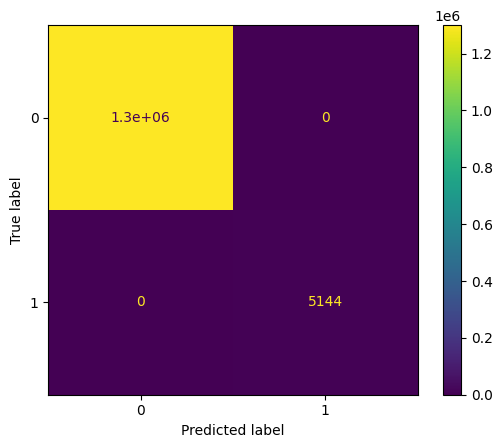

In [16]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [17]:
CatBoost = CatBoostClassifier(iterations=15, depth=5, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


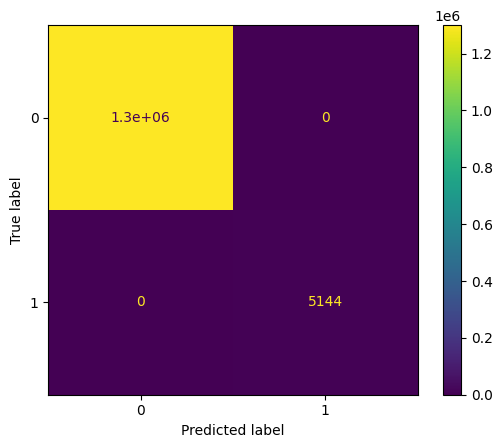

In [18]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [19]:
CatBoost = CatBoostClassifier(iterations=15, depth=6, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


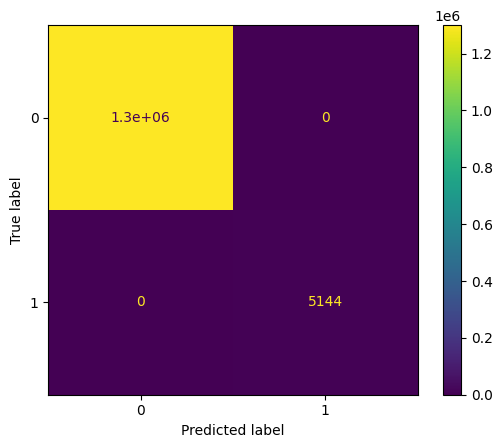

In [20]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [21]:
CatBoost = CatBoostClassifier(iterations=50, depth=5, auto_class_weights='Balanced', cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


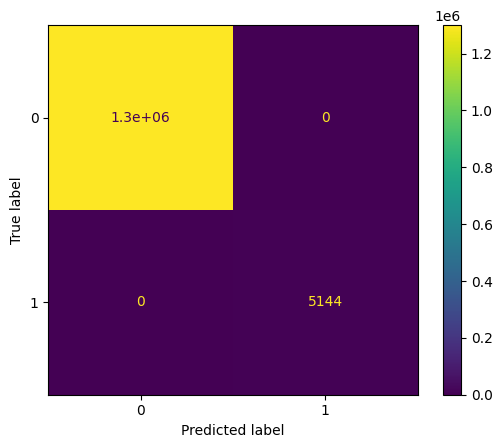

In [22]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

Попробуем настроить веса меток самостоятельно

In [23]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


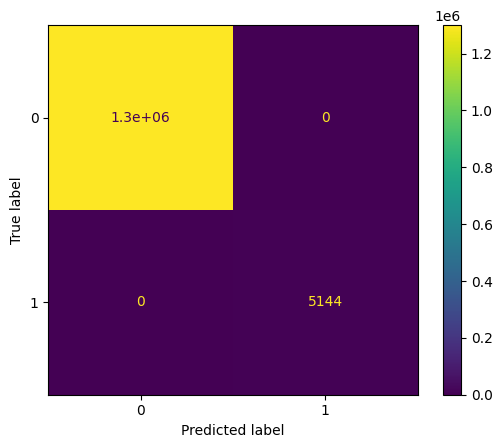

In [24]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [25]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


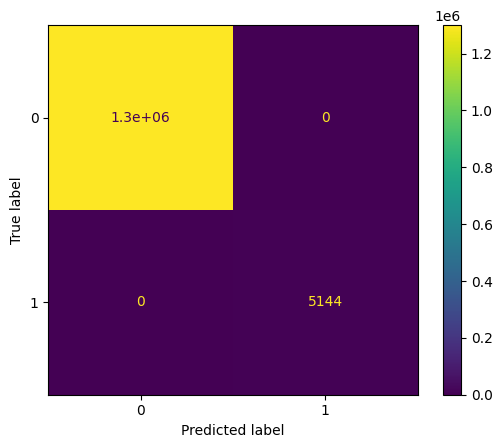

In [26]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [27]:
weights = {0: 1, 1: 100}
CatBoost = CatBoostClassifier(iterations=50, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


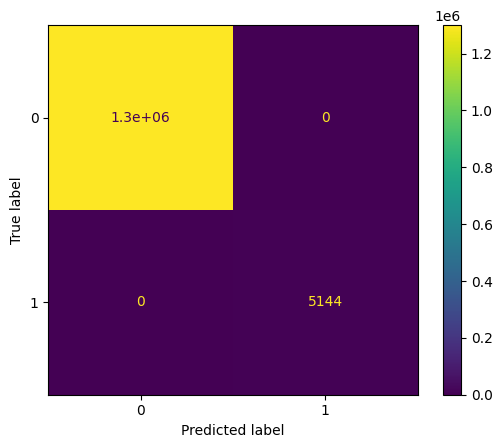

In [28]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [29]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


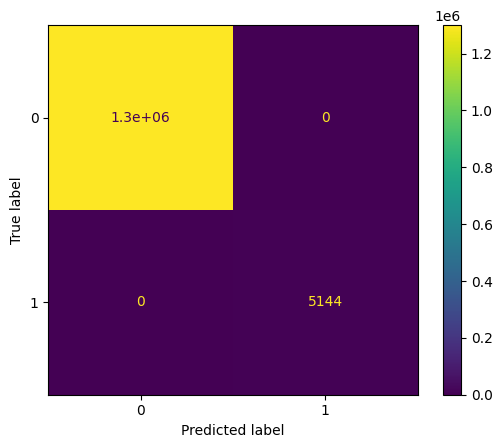

In [30]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [31]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=50, depth=6, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 0.9999999999999999

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 0.9999999999999999

Confusion matrix


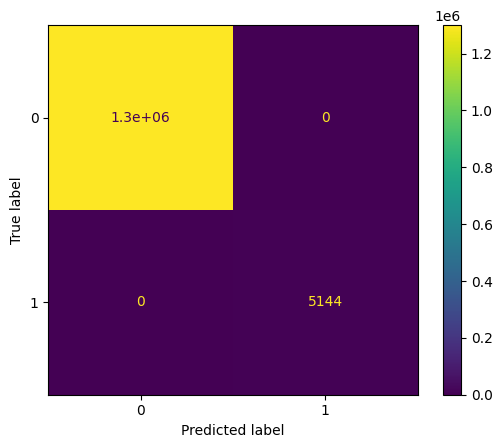

In [32]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [33]:
weights = {0: 1, 1: 1000}
CatBoost = CatBoostClassifier(iterations=50, depth=7, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


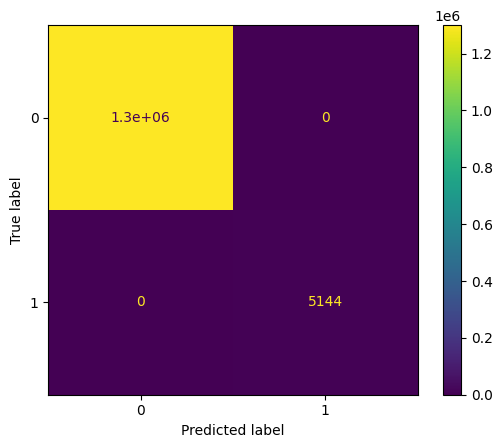

In [34]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [35]:
weights = {0: 1, 1: 800}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


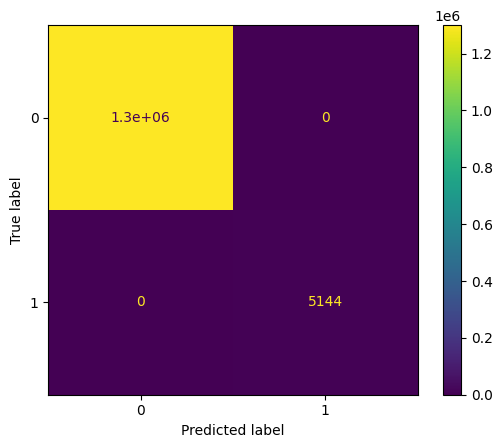

In [36]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [37]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=50, depth=4, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 0.9999999999999999

Confusion matrix


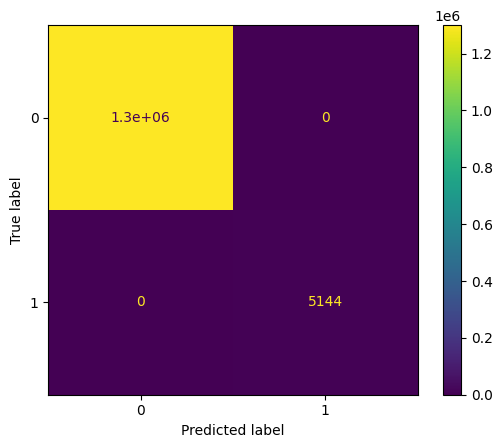

In [38]:
train_models(CatBoost, X_train, X_test, y_train, y_test)

In [39]:
weights = {0: 1, 1: 500}
CatBoost = CatBoostClassifier(iterations=50, depth=5, class_weights=weights, cat_features=cat_features, verbose=False)

Train metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Test metrics:
Accuracy: 1.0
Precision: 1.0
Recall: 1.0
F1-score: 1.0
PR-AUC: 1.0

Confusion matrix


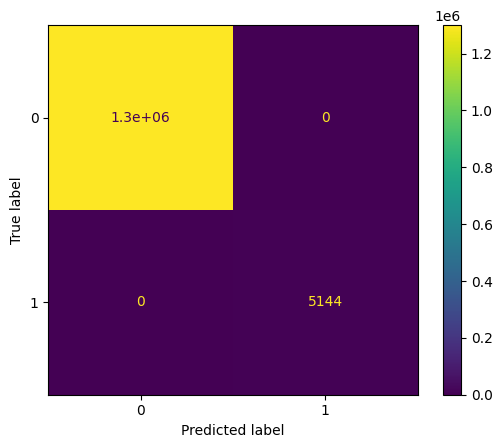

In [40]:
train_models(CatBoost, X_train, X_test, y_train, y_test)